# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [28]:
%pip install pandas numpy matplotlib

1535.51s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Label counts: [344 155]
Classification Report:
              precision    recall  f1-score   support

           0     0.8429    0.8551    0.8489        69
           1     0.6667    0.6452    0.6557        31

    accuracy                         0.7900       100
   macro avg     0.7548    0.7501    0.7523       100
weighted avg     0.7882    0.7900    0.7890       100



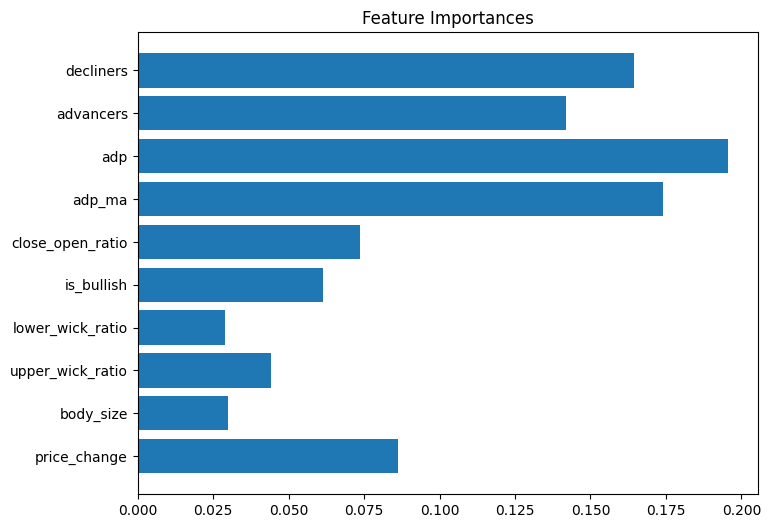

In [ ]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

# --- Step 1: Fetch 15m candles from Binance ---
def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500, end_time=None):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params)
    data = resp.json()
    df = pd.DataFrame(data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","qav","num_trades","taker_base","taker_quote","ignore"
    ])
    df = df[["open_time","open","high","low","close","volume"]].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

# --- Step 2: Fetch ADR data ---
def fetch_adr_series(size=500):
    url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
    resp = requests.get(url)
    j = resp.json()
    df_adr = pd.DataFrame({
        "timestamp": pd.to_datetime(j["data"]["timestamp"]),
        "adp_ma": j["data"]["adp_ma"],
        "advancers": j["data"]["advancers"],
        "decliners": j["data"]["decliners"],
        "adp": j["data"]["adp"],
        "total_volume": j["data"]["total_volume"]
    })
    return df_adr

# --- Step 3 + 4: Label spikes only if ADR below threshold (bearish market) ---
def label_spike_patterns_with_adr(df, adp_col="adp", adp_thresh=0.5, price_thresh=0.002, vol_ratio_thresh=1.01, window=12, bullish_run_min=6, body_size_thresh=0.004):
    """
    Label upward spikes where:
      - price change > price_thresh
      - volume spike > vol_ratio_thresh
      - ADR/ADP value < adp_thresh (bearish)
      - OR: at least bullish_run_min out of last window candles are bullish (close > open) AND average body_size > body_size_thresh
    """
    labels = []
    for i in range(len(df)):
        if i < window:
            labels.append(0)
            continue
        # Check ADR bearish condition
        adp_val = df.loc[i, adp_col]
        if np.isnan(adp_val) or adp_val >= adp_thresh:
            labels.append(0)
            continue
        prev_close = df.loc[i - 1, "close"]
        curr_close = df.loc[i, "close"]
        price_change = (curr_close - prev_close) / prev_close
        avg_vol = df.loc[i - window:i - 1, "volume"].mean()
        vol_ratio = df.loc[i, "volume"] / (avg_vol + 1e-6)
        # Bullish run detection with body size
        run_slice = df.loc[i - window + 1:i]
        bullish_count = (run_slice["close"] > run_slice["open"]).sum()
        avg_body_size = run_slice["body_size"].mean() / (run_slice["open"].mean() + 1e-6)
        if (price_change > price_thresh and vol_ratio > vol_ratio_thresh) or (bullish_count >= bullish_run_min and avg_body_size > body_size_thresh):
            labels.append(1)
        else:
            labels.append(0)
    df = df.copy()
    df["label"] = labels
    return df

# --- Step 4: feature engineering with ADR alignment ---
def add_features_with_adr_alignment(df_price, df_adr, window=12, adp_col="adp", adp_thresh=0.5, vol_ratio_thresh=1.01, bullish_run_min=6, body_size_thresh=0.004):
    df = df_price.copy()
    df = df.sort_values("timestamp").reset_index(drop=True)
    df_adr = df_adr.sort_values("timestamp").reset_index(drop=True)
    # Align adr with price candles by nearest previous timestamp
    df = pd.merge_asof(df, df_adr, on="timestamp", direction="backward")
    # Forward fill missing adr values just in case
    df[[adp_col, "adp_ma", "advancers", "decliners", "total_volume"]] = df[[adp_col, "adp_ma", "advancers", "decliners", "total_volume"]].bfill()
    # Calculate features as before
    df["price_change"] = df["close"].pct_change()
    df["body_size"] = abs(df["close"] - df["open"])
    df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
    df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
    df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
    df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
    df["is_bullish"] = (df["close"] > df["open"]).astype(int)
    df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
    df = df.dropna().reset_index(drop=True)
    # Label spikes only when adr indicates bearish market (adp < threshold)
    df = label_spike_patterns_with_adr(df, adp_col=adp_col, adp_thresh=adp_thresh, vol_ratio_thresh=vol_ratio_thresh, window=window, bullish_run_min=bullish_run_min, body_size_thresh=body_size_thresh)
    return df

# --- Step 5: Fetch data & build features ---
df_price = fetch_binance_klines("BANANAS31USDC", interval="15m", limit=500, end_time=1753706700000)
df_adr = fetch_adr_series(size=500)
df = add_features_with_adr_alignment(df_price, df_adr, adp_thresh=0.5, vol_ratio_thresh=1.01, window=12, bullish_run_min=6, body_size_thresh=0.004)

# --- Step 6: Model Training ---
feature_cols = [
    "price_change", "body_size", "upper_wick_ratio", "lower_wick_ratio",
    "is_bullish", "close_open_ratio", "adp_ma", "adp", "advancers", "decliners"
]

X = df[feature_cols]
y = df["label"]

# Print label counts only
print(f"Label counts: {np.bincount(y.astype(int)) if len(y) > 0 else 'empty'}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

if len(np.unique(y_train)) < 2:
    print("Not enough classes in training labels for classification.")
else:
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    clf.fit(X_train, y_train)

    # --- Step 7: Evaluation ---
    y_pred = clf.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    joblib.dump(clf, "./checkpoints/spikehunter_model.pkl")

    # Feature importance chart
    importances = clf.feature_importances_
    plt.figure(figsize=(8, 6))
    plt.barh(feature_cols, importances)
    plt.title("Feature Importances")
    plt.show()

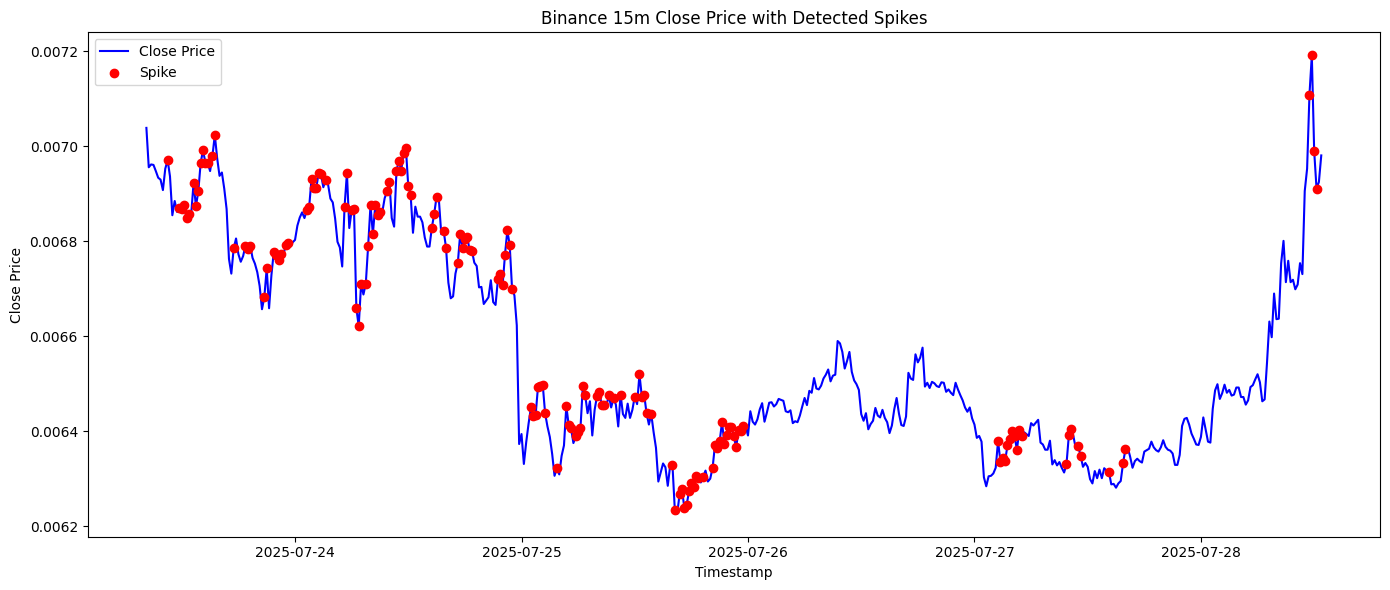

In [42]:
# --- Plot Binance klines and highlight detected spikes ---
plt.figure(figsize=(14,6))
plt.plot(df['timestamp'], df['close'], label='Close Price', color='blue')
spike_indices = df.index[df['label'] == 1]
plt.scatter(df.loc[spike_indices, 'timestamp'], df.loc[spike_indices, 'close'], color='red', label='Spike', zorder=5)
plt.title('Binance 15m Close Price with Detected Spikes')
plt.xlabel('Timestamp')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()